# Tutorial 3: Image Classification Using ANN and CNN

This notebook follows the sequence and flow extracted from the tutorial video.

Dataset used: **CIFAR-10** from `tensorflow.keras.datasets`.

The notebook includes:
1. Import necessary libraries  
2. Load and check the CIFAR-10 dataset  
3. Data preprocessing  
4. Image visualization  
5. Feature normalization  
6. Build, train, and evaluate ANN  
7. Generate classification report and confusion matrix for ANN  
8. Build, train, and evaluate CNN  
9. Predict and verify test set images


## 1. Import Necessary Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Used in the second half of the video for the heatmap [00:22:06]

## 2. Load and Check the CIFAR-10 Dataset

In [2]:
# Load the dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Check data dimensions [00:07:36]
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)
y_train shape: (50000, 1)


## 3. Data Preprocessing (Flatten Labels & Define Classes)

In [3]:
# Reshape the 2D label array into a 1D array [00:09:17]
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Define the 10 class names for CIFAR-10 [00:10:08]
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

## 4. Create Image Visualization Function & Plot Sample

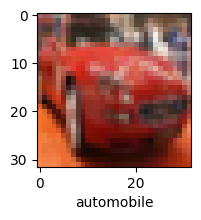

In [4]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15, 2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])
    plt.show()

# View the 5th sample image in the training set (Automobile) [00:13:04]
plot_sample(X_train, y_train, 5)

## 5. Feature Normalization

In [5]:
# Normalize pixel values to scale them between 0 and 1 [00:15:02]
X_train = X_train / 255.0
X_test = X_test / 255.0

## 6. Build and Train Artificial Neural Network (ANN)

In [6]:
# Build the ANN model
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the ANN [00:17:12]
ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model for 5 epochs [00:18:15]
ann.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 112s 71ms/step - accuracy: 0.3557 - loss: 1.8089
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 108s 69ms/step - accuracy: 0.4274 - loss: 1.6234
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 114s 73ms/step - accuracy: 0.4560 - loss: 1.5414
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 72ms/step - accuracy: 0.4779 - loss: 1.4817
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 71ms/step - accuracy: 0.4923 - loss: 1.4333


## 7. Evaluate ANN and Generate Classification Report with Heatmap

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.66      0.45      0.54      1000
           1       0.57      0.69      0.62      1000
           2       0.30      0.54      0.39      1000
           3       0.33      0.37      0.35      1000
           4       0.41      0.35      0.38      1000
           5       0.37      0.44      0.40      1000
           6       0.60      0.35      0.44      1000
           7       0.71      0.36      0.48      1000
           8       0.66      0.57      0.61      1000
           9       0.52      0.61      0.56      1000

    accuracy                           0.47     10000
   macro avg       0.51      0.47      0.48     10000
weighted avg       0.51      0.47      0.48     10000



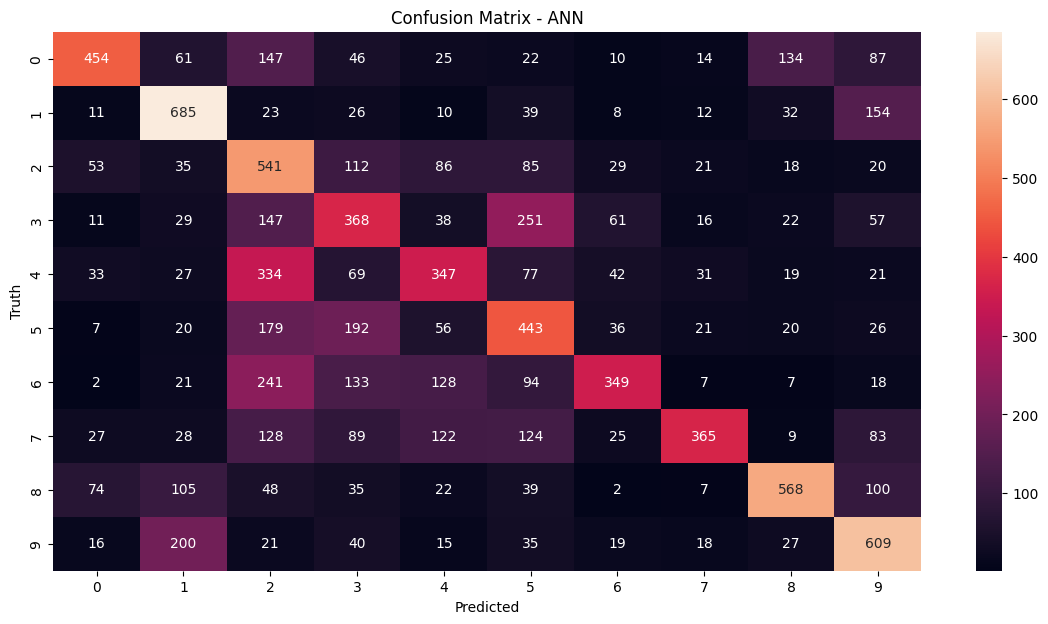

In [7]:
from sklearn.metrics import classification_report

# Predict on the test set [00:20:01]
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

# Print classification report [00:20:52]
print("Classification Report: \n", classification_report(y_test, y_pred_classes))

# Plot confusion matrix heatmap [00:22:06]
plt.figure(figsize=(14, 7))
sns.heatmap(tf.math.confusion_matrix(labels=y_test, predictions=y_pred_classes), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix - ANN')
plt.show()

## 8. Build and Train Convolutional Neural Network (CNN)

In [8]:
# Build the CNN model [00:24:09]
cnn = models.Sequential([
    # First Conv + Pooling layer
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Conv + Pooling layer
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the CNN [00:24:37]
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the CNN for 10 epochs [00:26:46]
cnn.fit(X_train, y_train, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 36ms/step - accuracy: 0.4789 - loss: 1.4488
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.6153 - loss: 1.0956
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.6664 - loss: 0.9563
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.6957 - loss: 0.8704
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 35ms/step - accuracy: 0.7233 - loss: 0.7937
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step - accuracy: 0.7440 - loss: 0.7321
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7628 - loss: 0.6791
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7791 - loss: 0.6306
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7949 - loss: 0.5829
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.8083 - loss: 0.5442


## 9. Evaluate CNN and Predict on Test Data

In [9]:
# Evaluate model accuracy on test data [00:28:03]
cnn.evaluate(X_test, y_test)

# Use CNN to make predictions [00:29:21]
y_pred = cnn.predict(X_test)

# Convert prediction probabilities to class index [00:30:06]
y_classes = [np.argmax(element) for element in y_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7020 - loss: 0.9337
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


## 10. Verify Test Set Predictions

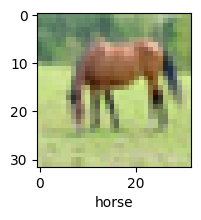

Predicted class: horse


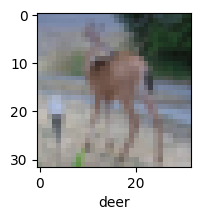

Predicted class: deer


In [10]:
# Check the 60th sample image in the test set (Horse) [00:31:05]
plot_sample(X_test, y_test, 60)

# Check if the model's prediction matches (Should output "horse") [00:33:52]
print("Predicted class:", classes[y_classes[60]])

# Check the 100th sample image in the test set (Deer) [00:31:41]
plot_sample(X_test, y_test, 100)
print("Predicted class:", classes[y_classes[100]])

---
# 11. Added Section: Enhanced CNN Model (`new_CNN`)

This section is added below the original tutorial code. The purpose of this section is to improve the original CNN model by adding data augmentation, batch normalization, dropout, and early stopping. The result of `new_CNN` can then be compared with the original CNN model.

## 11.1 Import Additional Libraries for `new_CNN`

Additional libraries are imported for early stopping, comparison table, and more detailed evaluation.

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

## 11.2 Re-evaluate the Original CNN Model

The original CNN model is evaluated again and its accuracy and loss are saved. These values are needed later for comparison with `new_CNN`.

In [12]:
# Re-evaluate original CNN and store the result for comparison
cnn_test_loss, cnn_test_accuracy = cnn.evaluate(X_test, y_test, verbose=2)

print("Original CNN Test Accuracy:", cnn_test_accuracy)
print("Original CNN Test Loss:", cnn_test_loss)

313/313 - 3s - 10ms/step - accuracy: 0.7020 - loss: 0.9337
Original CNN Test Accuracy: 0.7020000219345093
Original CNN Test Loss: 0.9336613416671753


## 11.3 Build the Enhanced `new_CNN` Model

The `new_CNN` model improves the original CNN architecture by adding:
- Data augmentation
- Additional convolutional block
- Batch normalization
- Dropout
- Early stopping during training

The three convolutional blocks use increasing numbers of filters: 32, 64, and 128. This helps the model learn simple, medium, and complex image features.

In [13]:
# Data augmentation layer
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

# Build the enhanced CNN model
new_CNN = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Data augmentation
    data_augmentation,

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

new_CNN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 11.4 Compile the `new_CNN` Model

The same loss function and evaluation metric are used so that the comparison with the original CNN is fair.

In [14]:
new_CNN.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 11.5 Train the `new_CNN` Model

Early stopping is used to stop training when the validation loss no longer improves. This helps reduce overfitting and prevents unnecessary training.

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_new_CNN = new_CNN.fit(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 133s 103ms/step - accuracy: 0.3399 - loss: 1.8314 - val_accuracy: 0.4244 - val_loss: 1.5779
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 126s 101ms/step - accuracy: 0.4414 - loss: 1.5579 - val_accuracy: 0.4827 - val_loss: 1.4683
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 129s 103ms/step - accuracy: 0.4877 - loss: 1.4355 - val_accuracy: 0.5302 - val_loss: 1.2489
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 128s 102ms/step - accuracy: 0.5215 - loss: 1.3497 - val_accuracy: 0.5824 - val_loss: 1.2204
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 145s 105ms/step - accuracy: 0.5486 - loss: 1.2880 - val_accuracy: 0.6163 - val_loss: 1.0950
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 131s 104ms/step - accuracy: 0.5780 - loss: 1.2184 - val_accuracy: 0.5421 - val_loss: 1.4497
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 139s 102ms/step - accuracy: 0.5904 - loss: 1.1741 - val_accuracy: 0.6479 - val_loss: 1.0229
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 127s 101ms/step - ac

## 11.6 Evaluate the `new_CNN` Model

The enhanced model is evaluated using the same CIFAR-10 test dataset.

In [16]:
new_cnn_test_loss, new_cnn_test_accuracy = new_CNN.evaluate(X_test, y_test, verbose=2)

print("new_CNN Test Accuracy:", new_cnn_test_accuracy)
print("new_CNN Test Loss:", new_cnn_test_loss)

313/313 - 8s - 25ms/step - accuracy: 0.7175 - loss: 0.8351
new_CNN Test Accuracy: 0.7174999713897705
new_CNN Test Loss: 0.8351135849952698


## 11.7 Compare Original CNN and `new_CNN`

This table compares the test accuracy and test loss of the original CNN and the enhanced `new_CNN` model.

In [17]:
comparison_df = pd.DataFrame({
    "Model": ["Original CNN", "new_CNN"],
    "Test Accuracy": [cnn_test_accuracy, new_cnn_test_accuracy],
    "Test Loss": [cnn_test_loss, new_cnn_test_loss]
})

comparison_df

,Model,Test Accuracy,Test Loss
0,Original CNN,0.7020,0.933661
1,new_CNN,0.7175,0.835114


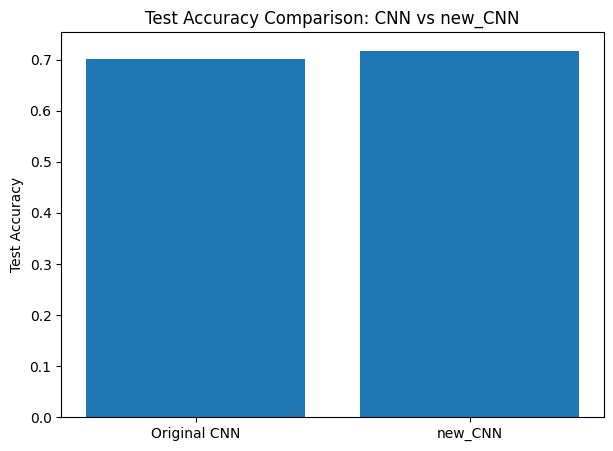

In [18]:
plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("Test Accuracy Comparison: CNN vs new_CNN")
plt.ylabel("Test Accuracy")
plt.show()

## 11.8 Plot Training and Validation Performance of `new_CNN`

The accuracy and loss graphs are plotted to observe the training process and check whether overfitting occurs.

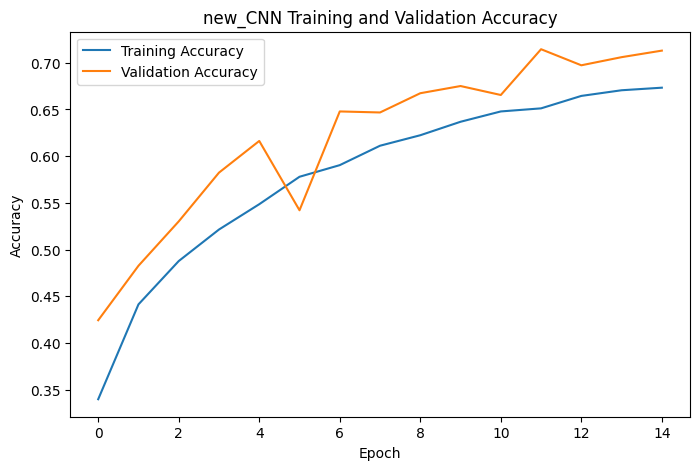

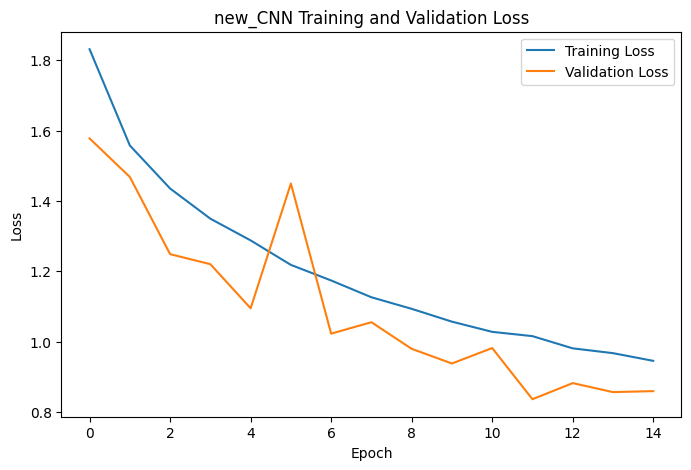

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history_new_CNN.history['accuracy'], label='Training Accuracy')
plt.plot(history_new_CNN.history['val_accuracy'], label='Validation Accuracy')
plt.title('new_CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_new_CNN.history['loss'], label='Training Loss')
plt.plot(history_new_CNN.history['val_loss'], label='Validation Loss')
plt.title('new_CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 11.9 Classification Report and Confusion Matrix for `new_CNN`

Precision, recall, F1-score, and confusion matrix are generated to provide a more detailed evaluation of the enhanced model.

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step
Classification Report for new_CNN:

              precision    recall  f1-score   support

    airplane       0.69      0.80      0.74      1000
  automobile       0.80      0.89      0.84      1000
        bird       0.71      0.55      0.62      1000
         cat       0.56      0.50      0.53      1000
        deer       0.78      0.54      0.64      1000
         dog       0.67      0.62      0.64      1000
        frog       0.76      0.78      0.77      1000
       horse       0.67      0.84      0.74      1000
        ship       0.88      0.78      0.83      1000
       truck       0.69      0.87      0.77      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.71     10000
weighted avg       0.72      0.72      0.71     10000



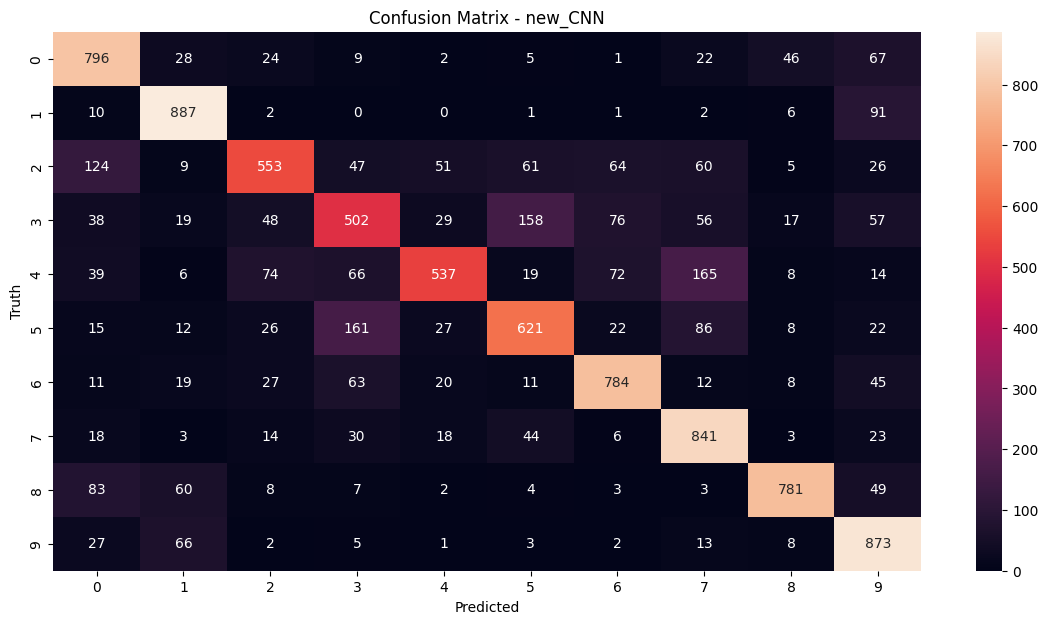

In [20]:
new_cnn_predictions = new_CNN.predict(X_test)
new_cnn_classes = [np.argmax(element) for element in new_cnn_predictions]

print("Classification Report for new_CNN:\n")
print(classification_report(y_test, new_cnn_classes, target_names=classes))

plt.figure(figsize=(14, 7))
sns.heatmap(
    tf.math.confusion_matrix(labels=y_test, predictions=new_cnn_classes),
    annot=True,
    fmt='d'
)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix - new_CNN')
plt.show()

## 11.10 Verify `new_CNN` Predictions on Test Images

The prediction output of `new_CNN` is checked using the same sample images used earlier in the tutorial.

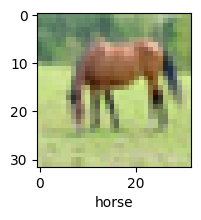

Actual class: horse
new_CNN Predicted class: horse


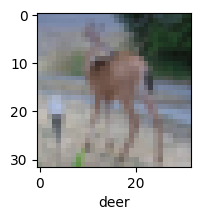

Actual class: deer
new_CNN Predicted class: horse


In [21]:
# Check the 60th sample image
plot_sample(X_test, y_test, 60)
print("Actual class:", classes[y_test[60]])
print("new_CNN Predicted class:", classes[new_cnn_classes[60]])

# Check the 100th sample image
plot_sample(X_test, y_test, 100)
print("Actual class:", classes[y_test[100]])
print("new_CNN Predicted class:", classes[new_cnn_classes[100]])